Original Dataset Shape: (1665, 80)
Cleaned Dataset Shape: (1661, 9)

Cycle Count Statistics:
count    159.000000
mean      10.446541
std        7.034857
min        1.000000
25%        5.000000
50%       12.000000
75%       13.000000
max       45.000000
dtype: float64

Final Sequence Shape: (1219, 3, 7)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 3, 7)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 3, 7)      │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 3)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 3, 256)    │    139,264 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 3, 256)    │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ dropout[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 312,132 (1.19 MB)

 Trainable params: 312,132 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.8479 - mae: 0.6084 - val_loss: 0.7781 - val_mae: 0.6186
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.6758 - mae: 0.5565 - val_loss: 0.7469 - val_mae: 0.5897
Epoch 3/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6214 - mae: 0.5254 - val_loss: 0.7309 - val_mae: 0.5765
Epoch 4/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6226 - mae: 0.5183 - val_loss: 0.7233 - val_mae: 0.5704
Epoch 5/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.6003 - mae: 0.5167 - val_loss: 0.7278 - val_mae: 0.5730
Epoch 6/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.5926 - mae: 0.5155 - val_loss: 0.7231 - val_mae: 0.5701
Epoch 7/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.5919 - mae: 0.5137 - val_loss: 0.7225 - val_mae: 0.5703
Epoch 8/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.5729 - mae: 0.5091 - val_loss: 0.7218 - val_mae: 0.5708
Epoch 9/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.59

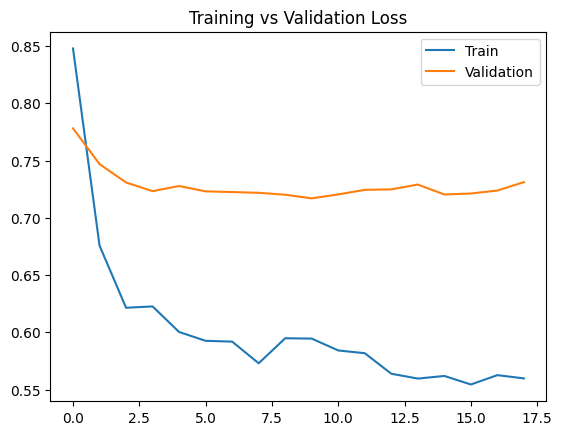


Sample Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
{'Predicted Cycle Length (days)': 28, 'Next Period Start Date': '2023-01-29', 'Predicted Ovulation Date': '2023-01-16', 'Fertile Window Start': '2023-01-11', 'Fertile Window End': '2023-01-17', 'Predicted Menses Duration (days)': 6, 'Predicted Luteal Phase (days)': 14}


In [1]:
# ==========================================================
# PRODUCTION-GRADE MENSTRUAL INTELLIGENCE ENGINE
# Multi-Task LSTM with Edge-Case Handling
# ==========================================================

# ==============================
# 1️⃣ IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    Masking, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping
from datetime import datetime, timedelta

np.random.seed(42)
tf.random.set_seed(42)

# ==========================================================
# 2️⃣ LOAD DATA
# ==========================================================

df = pd.read_csv("FedCycleData071012.csv", encoding="utf-8-sig")

print("Original Dataset Shape:", df.shape)

# ==========================================================
# 3️⃣ SELECT ONLY APP-COLLECTABLE FEATURES
# ==========================================================

usable_columns = [
    "ClientID",
    "CycleNumber",
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "Age",
    "BMI",
    "CycleWithPeakorNot"
]

df = df[usable_columns]

# Convert to numeric safely
numeric_cols = [
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "Age",
    "BMI"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================================================
# 4️⃣ BIOLOGICAL FILTERING (REALISTIC CONSTRAINTS)
# ==========================================================

df = df[
    (df["LengthofCycle"].between(18, 60)) &
    (df["LengthofMenses"].between(2, 15))
]

# Fill remaining missing numeric values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Sort properly
df = df.sort_values(["ClientID", "CycleNumber"]).reset_index(drop=True)

print("Cleaned Dataset Shape:", df.shape)

# ==========================================================
# 5️⃣ ANALYZE USER HISTORY DISTRIBUTION
# ==========================================================

cycle_counts = df.groupby("ClientID").size()

print("\nCycle Count Statistics:")
print(cycle_counts.describe())

# ==========================================================
# 6️⃣ BUILD SEQUENCE DATASET
# ==========================================================

WINDOW_SIZE = 3  # smaller window to preserve data

X = []
y = []

for client in df["ClientID"].unique():

    client_data = df[df["ClientID"] == client].reset_index(drop=True)

    if len(client_data) > WINDOW_SIZE:

        for i in range(len(client_data) - WINDOW_SIZE):

            window = client_data.iloc[i:i+WINDOW_SIZE]
            target = client_data.iloc[i+WINDOW_SIZE]

            sequence = window[[
                "LengthofCycle",
                "LengthofMenses",
                "EstimatedDayofOvulation",
                "LengthofLutealPhase",
                "Age",
                "BMI",
                "CycleWithPeakorNot"
            ]].values

            target_values = [
                target["LengthofCycle"],
                target["EstimatedDayofOvulation"],
                target["LengthofLutealPhase"],
                target["LengthofMenses"]
            ]

            X.append(sequence)
            y.append(target_values)

X = np.array(X)
y = np.array(y)

print("\nFinal Sequence Shape:", X.shape)

if len(X) == 0:
    raise ValueError("No valid sequences created. Reduce WINDOW_SIZE or inspect dataset.")

# ==========================================================
# 7️⃣ ROBUST SCALING (handles outliers better)
# ==========================================================

feature_scaler = RobustScaler()
target_scaler = RobustScaler()

X_reshaped = X.reshape(-1, X.shape[2])
X_scaled = feature_scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape)

y_scaled = target_scaler.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# ==========================================================
# 8️⃣ MODEL ARCHITECTURE (Bidirectional LSTM)
# ==========================================================

input_layer = Input(shape=(WINDOW_SIZE, X.shape[2]))

x = Masking(mask_value=0.0)(input_layer)

x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64))(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)

output = Dense(4)(x)  # Multi-output regression

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

# ==========================================================
# 9️⃣ TRAINING
# ==========================================================

early_stop = EarlyStopping(patience=8, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 🔟 EVALUATION
# ==========================================================

pred_scaled = model.predict(X_test)
pred = target_scaler.inverse_transform(pred_scaled)
true = target_scaler.inverse_transform(y_test)

print("\nEvaluation (MAE per Target):")

labels = ["Cycle", "Ovulation", "Luteal", "Menses"]

for i, label in enumerate(labels):
    mae = mean_absolute_error(true[:, i], pred[:, i])
    print(f"{label} MAE: {mae:.2f} days")

# ==========================================================
# 1️⃣1️⃣ LOSS VISUALIZATION
# ==========================================================

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()

# ==========================================================
# 1️⃣2️⃣ APP PREDICTION FUNCTION
# ==========================================================

def predict_user_next_cycle_with_dates(user_history, last_period_start_date):
    """
    user_history: shape (WINDOW_SIZE, 7)
    last_period_start_date: string format 'YYYY-MM-DD'
    """

    user_history = np.array(user_history)

    if user_history.shape != (WINDOW_SIZE, X.shape[2]):
        raise ValueError(f"Input must be shape ({WINDOW_SIZE}, {X.shape[2]})")

    # Scale input
    user_scaled = feature_scaler.transform(
        user_history.reshape(-1, X.shape[2])
    ).reshape(1, WINDOW_SIZE, X.shape[2])

    # Predict
    pred_scaled = model.predict(user_scaled)
    pred = target_scaler.inverse_transform(pred_scaled)

    predicted_cycle = round(float(pred[0][0]))
    predicted_ovulation_day = round(float(pred[0][1]))
    predicted_luteal = round(float(pred[0][2]))
    predicted_menses = round(float(pred[0][3]))

    # Convert last period date
    last_period_date = datetime.strptime(last_period_start_date, "%Y-%m-%d")

    # Calculate predicted next period start
    next_period_date = last_period_date + timedelta(days=predicted_cycle)

    # Ovulation date
    ovulation_date = last_period_date + timedelta(days=predicted_ovulation_day)

    # Fertility window (approx 5 days before ovulation)
    fertile_start = ovulation_date - timedelta(days=5)
    fertile_end = ovulation_date + timedelta(days=1)

    return {
        "Predicted Cycle Length (days)": predicted_cycle,
        "Next Period Start Date": next_period_date.strftime("%Y-%m-%d"),
        "Predicted Ovulation Date": ovulation_date.strftime("%Y-%m-%d"),
        "Fertile Window Start": fertile_start.strftime("%Y-%m-%d"),
        "Fertile Window End": fertile_end.strftime("%Y-%m-%d"),
        "Predicted Menses Duration (days)": predicted_menses,
        "Predicted Luteal Phase (days)": predicted_luteal
    }

# ==========================================================
# 1️⃣3️⃣ SAMPLE TEST
# ==========================================================

sample_input = X[0]
print("\nSample Prediction:")
# Fix: Use the correct function name and provide a sample date for last_period_start_date
print(predict_user_next_cycle_with_dates(sample_input, "2023-01-01"))

In [2]:
pcos_df = pd.read_csv("/content/PCOS_data.csv")
print("Original Shape:", pcos_df.shape)

Original Shape: (541, 45)


In [3]:
pcos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
pcos_df = pd.read_csv("PCOS_data.csv")  # change if needed

print("Original Shape:", pcos_df.shape)

# --------------------------------------------------
# Normalize column names (bulletproof cleaning)
# --------------------------------------------------
pcos_df.columns = (
    pcos_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace(".", "")
    .str.replace("/", "_")
)

print("\nCleaned Columns:")
print(pcos_df.columns.tolist())

Original Shape: (541, 45)

Cleaned Columns:
['Sl_No', 'Patient_File_No', 'PCOS_Y_N', 'Age_yrs', 'Weight_Kg', 'HeightCm', 'BMI', 'Blood_Group', 'Pulse_ratebpm', 'RR_breaths_min', 'Hbg_dl', 'CycleR_I', 'Cycle_lengthdays', 'Marraige_Status_Yrs', 'PregnantY_N', 'No_of_abortions', 'I___beta-HCGmIU_mL', 'II____beta-HCGmIU_mL', 'FSHmIU_mL', 'LHmIU_mL', 'FSH_LH', 'Hipinch', 'Waistinch', 'Waist:Hip_Ratio', 'TSH_mIU_L', 'AMHng_mL', 'PRLng_mL', 'Vit_D3_ng_mL', 'PRGng_mL', 'RBSmg_dl', 'Weight_gainY_N', 'hair_growthY_N', 'Skin_darkening_Y_N', 'Hair_lossY_N', 'PimplesY_N', 'Fast_food_Y_N', 'RegExerciseY_N', 'BP__Systolic_mmHg', 'BP__Diastolic_mmHg', 'Follicle_No_L', 'Follicle_No_R', 'Avg_F_size_L_mm', 'Avg_F_size_R_mm', 'Endometrium_mm', 'Unnamed:_44']


In [5]:
print(pcos_df.columns.tolist())

['Sl_No', 'Patient_File_No', 'PCOS_Y_N', 'Age_yrs', 'Weight_Kg', 'HeightCm', 'BMI', 'Blood_Group', 'Pulse_ratebpm', 'RR_breaths_min', 'Hbg_dl', 'CycleR_I', 'Cycle_lengthdays', 'Marraige_Status_Yrs', 'PregnantY_N', 'No_of_abortions', 'I___beta-HCGmIU_mL', 'II____beta-HCGmIU_mL', 'FSHmIU_mL', 'LHmIU_mL', 'FSH_LH', 'Hipinch', 'Waistinch', 'Waist:Hip_Ratio', 'TSH_mIU_L', 'AMHng_mL', 'PRLng_mL', 'Vit_D3_ng_mL', 'PRGng_mL', 'RBSmg_dl', 'Weight_gainY_N', 'hair_growthY_N', 'Skin_darkening_Y_N', 'Hair_lossY_N', 'PimplesY_N', 'Fast_food_Y_N', 'RegExerciseY_N', 'BP__Systolic_mmHg', 'BP__Diastolic_mmHg', 'Follicle_No_L', 'Follicle_No_R', 'Avg_F_size_L_mm', 'Avg_F_size_R_mm', 'Endometrium_mm', 'Unnamed:_44']


In [6]:
# ==========================================================
# FINAL APP-COMPATIBLE PCOS MODEL
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Dataset already loaded and columns cleaned

# ----------------------------------------------------------
# 1️⃣ Select App-Compatible Features
# ----------------------------------------------------------

app_features = [
    "PCOS_Y_N",
    "Age_yrs",
    "BMI",
    "CycleR_I",
    "Cycle_lengthdays",
    "Weight_gainY_N",
    "hair_growthY_N",
    "Skin_darkening_Y_N",
    "Hair_lossY_N",
    "PimplesY_N",
    "Fast_food_Y_N",
    "RegExerciseY_N"
]

pcos_model_df = pcos_df[app_features].copy()

# ----------------------------------------------------------
# 2️⃣ Clean Data
# ----------------------------------------------------------

pcos_model_df = pcos_model_df.apply(pd.to_numeric, errors="coerce")
pcos_model_df = pcos_model_df.fillna(pcos_model_df.median())

# ----------------------------------------------------------
# 3️⃣ Feature Engineering (Aligned with LSTM)
# ----------------------------------------------------------

# Cycle deviation from normal
pcos_model_df["cycle_variation"] = abs(
    pcos_model_df["Cycle_lengthdays"] - 28
)

# High BMI indicator
pcos_model_df["high_bmi"] = (
    pcos_model_df["BMI"] > 25
).astype(int)

# Symptom severity score
pcos_model_df["symptom_score"] = (
    pcos_model_df["Weight_gainY_N"] +
    pcos_model_df["hair_growthY_N"] +
    pcos_model_df["Skin_darkening_Y_N"] +
    pcos_model_df["Hair_lossY_N"] +
    pcos_model_df["PimplesY_N"]
)

# Lifestyle risk
pcos_model_df["lifestyle_risk"] = (
    pcos_model_df["Fast_food_Y_N"] -
    pcos_model_df["RegExerciseY_N"]
)

# ----------------------------------------------------------
# 4️⃣ Train Model
# ----------------------------------------------------------

feature_cols = [
    "Age_yrs",
    "BMI",
    "Cycle_lengthdays",
    "CycleR_I",
    "cycle_variation",
    "high_bmi",
    "symptom_score",
    "lifestyle_risk"
]

X = pcos_model_df[feature_cols]
y = pcos_model_df["PCOS_Y_N"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_pcos = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3
)

model_pcos.fit(X_train, y_train)

# ----------------------------------------------------------
# 5️⃣ Evaluation
# ----------------------------------------------------------

y_pred = model_pcos.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[74  3]
 [ 9 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93        77
           1       0.88      0.72      0.79        32

    accuracy                           0.89       109
   macro avg       0.89      0.84      0.86       109
weighted avg       0.89      0.89      0.89       109



In [7]:
def analyze_user_pcos(
    cycle_history,
    predicted_cycle_length,
    age,
    bmi,
    weight_gain,
    hair_growth,
    skin_darkening,
    hair_loss,
    pimples,
    fast_food,
    exercise
):

    cycle_std = np.std(cycle_history)
    irregular = 1 if cycle_std > 4 else 0

    cycle_variation = abs(predicted_cycle_length - 28)
    high_bmi = 1 if bmi > 25 else 0

    symptom_score = (
        weight_gain +
        hair_growth +
        skin_darkening +
        hair_loss +
        pimples
    )

    lifestyle_risk = fast_food - exercise

    user_df = pd.DataFrame([{
        "Age_yrs": age,
        "BMI": bmi,
        "Cycle_lengthdays": predicted_cycle_length,
        "CycleR_I": irregular,
        "cycle_variation": cycle_variation,
        "high_bmi": high_bmi,
        "symptom_score": symptom_score,
        "lifestyle_risk": lifestyle_risk
    }])

    prob = model_pcos.predict_proba(user_df)[0][1]

    risk_level = (
        "Low" if prob < 0.4 else
        "Medium" if prob < 0.7 else
        "High"
    )

    return {
        "PCOS Probability": round(float(prob), 3),
        "Risk Level": risk_level
    }

In [8]:
# Save LSTM
model.save("cycle_model.h5")

# Save scalers
import joblib
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

# Save PCOS model
joblib.dump(model_pcos, "pcos_model.pkl")

['pcos_model.pkl']